In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load datasets using relative paths

train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")
meal_info_data = pd.read_csv("meal_info.csv")
fulfilment_center_info_data = pd.read_csv("fulfilment_center_info.csv")

print("✅ All datasets loaded successfully.")

✅ All datasets loaded successfully.


In [3]:
print("Train:", train_data.shape)
print("Test:", test_data.shape)
print("Meal info:", meal_info_data.shape)
print("Fulfilment center info:", fulfilment_center_info_data.shape)
print("Sample submission:", sample.shape)

Train: (456548, 9)
Test: (32573, 8)
Meal info: (51, 3)
Fulfilment center info: (77, 5)
Sample submission: (32573, 2)


In [4]:
train_data.info()
print()
print(train_data.head())
print() 
print()
test_data.info()
print()
print(test_data.head())
print() 
print()
sample.info()
print()
print(sample.head())
print() 
print()
meal_info_data.info()
print()
print(meal_info_data.head())
print() 
print()
fulfilment_center_info_data.info()
print()
print(fulfilment_center_info_data.head())

<class 'pandas.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 31.3 MB

        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.

In [5]:
print(train_data.dtypes)

id                         int64
week                       int64
center_id                  int64
meal_id                    int64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
num_orders                 int64
dtype: object


In [6]:
train = pd.merge(train_data, fulfilment_center_info_data, how="left", on="center_id")
train = pd.merge(train, meal_info_data, how="left", on="meal_id")

# Display information about the merged train dataset
train.info()
print()

# Merge test and fulfilment_center_info datasets
test = pd.merge(test_data, fulfilment_center_info_data, how="left", on="center_id")
test = pd.merge(test, meal_info_data, how="left", on="meal_id")

# Display information about the merged test dataset
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
 9   city_code              456548 non-null  int64  
 10  region_code            456548 non-null  int64  
 11  center_type            456548 non-null  str    
 12  op_area                456548 non-null  float64
 13  category               456548 non-null  str    
 14  cuisine                456548 non-null  str    

In [7]:
train.describe()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000,456548.000000,456548.000000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760,601.553399,56.614566,4.083590
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798,66.195914,17.641306,1.091686
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000,456.000000,23.000000,0.900000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000,553.000000,34.000000,3.600000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000,596.000000,56.000000,4.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000,651.000000,77.000000,4.500000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000,713.000000,93.000000,7.000000


In [8]:
train.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64

In [9]:
train.duplicated().sum()

np.int64(0)

In [10]:
train.sample()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
253657,1050599,83,132,2492,293.0,389.03,0,0,13,522,56,TYPE_A,3.9,Desert,Indian


In [11]:
test.describe()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,city_code,region_code,op_area
count,3.257300e+04,32573.000000,32573.000000,32573.000000,32573.000000,32573.000000,32573.000000,32573.000000,32573.000000,32573.000000,32573.000000
mean,1.248476e+06,150.477819,81.901728,2032.067909,341.854440,356.493615,0.066435,0.081356,601.519971,56.712154,4.087726
std,1.441580e+05,2.864072,45.950455,547.199004,153.893886,155.150101,0.249045,0.273385,65.996677,17.641174,1.098835
min,1.000085e+06,146.000000,10.000000,1062.000000,67.900000,89.240000,0.000000,0.000000,456.000000,23.000000,0.900000
25%,1.123969e+06,148.000000,43.000000,1558.000000,214.430000,243.500000,0.000000,0.000000,556.000000,34.000000,3.600000
50%,1.247296e+06,150.000000,76.000000,1993.000000,320.130000,321.130000,0.000000,0.000000,596.000000,56.000000,4.000000
75%,1.372971e+06,153.000000,110.000000,2569.000000,446.230000,455.930000,0.000000,0.000000,651.000000,77.000000,4.500000
max,1.499996e+06,155.000000,186.000000,2956.000000,1113.620000,1112.620000,1.000000,1.000000,713.000000,93.000000,7.000000


In [12]:
test.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64

In [13]:
test.duplicated().sum()

np.int64(0)

In [14]:
test.sample()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,city_code,region_code,center_type,op_area,category,cuisine
25674,1059505,153,80,1962,564.6,564.6,0,0,604,56,TYPE_C,5.1,Pizza,Continental


In [15]:
data = [train,test]
print(data)

[             id  week  center_id  meal_id  checkout_price  base_price  \
0       1379560     1         55     1885          136.83      152.29   
1       1466964     1         55     1993          136.83      135.83   
2       1346989     1         55     2539          134.86      135.86   
3       1338232     1         55     2139          339.50      437.53   
4       1448490     1         55     2631          243.50      242.50   
...         ...   ...        ...      ...             ...         ...   
456543  1271326   145         61     1543          484.09      484.09   
456544  1062036   145         61     2304          482.09      482.09   
456545  1110849   145         61     2664          237.68      321.07   
456546  1147725   145         61     2569          243.50      313.34   
456547  1361984   145         61     2490          292.03      290.03   

        emailer_for_promotion  homepage_featured  num_orders  city_code  \
0                           0                  

In [16]:
# List number of rows in train dataframe
train_rows = len(train)
print(train_rows)

# List number of rows in test dataframe
test_rows = len(test)
print(test_rows)

# Number of unique values in "id" column for both dataframes
train_id = train["id"].nunique()
test_id = test["id"].nunique()

print(train_id)
print(test_id)

456548
32573
456548
32573


In [17]:
for dataset in data:
    dataset.drop(["id"], axis = 1, inplace = True)

In [18]:
# Number of unique values in "week" column for both dataframes
train_week = train["week"].nunique()
test_week = test["week"].nunique()

print(train_week)
print(test_week)

145
10


In [19]:
# Number of counts in "week" column for both dataframes
train_week_count = train["week"].value_counts()
test_week_count = test["week"].value_counts()

print(train_week_count)
print("-" * 100)
print(test_week_count)

week
122    3359
105    3348
106    3347
140    3332
123    3331
       ... 
13     2838
12     2831
14     2830
7      2795
8      2786
Name: count, Length: 145, dtype: int64
----------------------------------------------------------------------------------------------------
week
148    3332
149    3313
150    3277
147    3271
153    3268
152    3242
146    3240
154    3228
151    3224
155    3178
Name: count, dtype: int64


In [20]:
# Number of unique values in "center_id" column for both dataframes
train_center_id = train["center_id"].nunique()
test_center_id = test["center_id"].nunique()

print(train_center_id)
print(test_center_id)

77
77


In [21]:
# Number of counts in "center_id" column for both dataframes
train_center_id_count = train["center_id"].value_counts()
test_center_id_count = test["center_id"].value_counts()

print(train_center_id_count)
print("-" * 100)
print(test_center_id_count)

center_id
13     7046
10     7015
52     6993
43     6970
67     6915
       ... 
139    4627
57     4501
162    4366
41     4083
91     3432
Name: count, Length: 77, dtype: int64
----------------------------------------------------------------------------------------------------
center_id
13     509
10     508
52     506
174    504
67     499
      ... 
139    321
57     311
162    310
41     299
91     280
Name: count, Length: 77, dtype: int64


In [22]:
# Number of unique values in "city_code" column for both dataframes
train_city_code = train["city_code"].nunique()
test_city_code = test["city_code"].nunique()

print(train_city_code)
print(test_city_code)

51
51


In [23]:
# Number of counts in "city_code" column for both dataframes
train_city_code_count = train["city_code"].value_counts()
test_city_code_count = test["city_code"].value_counts()

print(train_city_code_count)
print("-" * 100)
print(test_city_code_count)

city_code
590    54746
526    43525
638    20047
522    13459
517    13109
604    13062
699    12098
647    11833
576    11456
614    11332
676    11177
593    10804
685     6993
700     6891
713     6853
579     6843
679     6801
456     6716
703     6706
698     6434
577     6389
599     6296
596     6293
648     6090
602     6057
659     6053
654     6041
628     5983
651     5975
562     5938
615     5892
556     5885
473     5855
561     5846
461     5763
620     5732
609     5721
675     5715
485     5712
658     5591
553     5547
649     5528
680     5379
683     5296
695     5296
632     5292
702     5264
515     5085
478     5021
693     4627
541     4501
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
city_code
590    3962
526    3064
638    1436
522     971
517     930
604     927
614     896
699     860
647     834
576     820
676     796
593     752
685     506
700     504
579     487
713     48

In [24]:
# Number of unique values in "region_code" column for both dataframes
train_region_code = train["region_code"].nunique()
test_region_code = test["region_code"].nunique()

print(train_region_code)
print(test_region_code)

8
8


In [25]:
# Number of counts in "region_code" column for both dataframes
train_region_code_count = train["region_code"].value_counts()
test_region_code_count = test["region_code"].value_counts()

print(train_region_code_count)
print("-" * 100)
print(test_region_code_count)

region_code
56    191228
34    116713
77     94612
85     30283
23      6434
71      6293
93      5721
35      5264
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
region_code
56    13683
34     8265
77     6688
85     2238
71      468
23      449
93      412
35      370
Name: count, dtype: int64


In [26]:
# Number of unique values in "center_type" column for both dataframes
train_center_type = train["center_type"].nunique()
test_center_type = test["center_type"].nunique()

print(train_center_type)
print(test_center_type)

3
3


In [27]:
# Number of counts in "center_type" column for both dataframes
train_center_type_count = train["center_type"].value_counts()
test_center_type_count = test["center_type"].value_counts()

print(train_center_type_count)
print("-" * 100)
print(test_center_type_count)

center_type
TYPE_A    262881
TYPE_C     99593
TYPE_B     94074
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
center_type
TYPE_A    18716
TYPE_C     7009
TYPE_B     6848
Name: count, dtype: int64


In [28]:
# Number of unique values in "op_area" column for both dataframes
train_op_area = train["op_area"].nunique()
test_op_area = test["op_area"].nunique()

print(train_op_area)
print(test_op_area)

30
30


In [29]:
# Number of counts in "op_area" column for both dataframes
train_op_area_count = train["op_area"].value_counts()
test_op_area_count = test["op_area"].value_counts()

print(train_op_area_count)
print("-" * 100)
print(test_op_area_count)

op_area
4.0    52548
3.9    48533
3.8    40080
4.4    26060
4.5    25688
2.8    25503
4.1    23346
7.0    20686
4.8    18648
3.4    17258
3.6    16821
5.1    13366
4.2    12608
2.7    12430
3.0    11184
2.0     9512
6.7     7046
6.3     7015
5.6     6993
3.7     6801
3.5     6666
3.2     6333
5.0     6164
5.3     6053
4.6     5983
4.7     5975
2.4     5021
2.9     4712
1.9     4083
0.9     3432
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
op_area
4.0    3747
3.9    3435
3.8    2853
4.4    1855
4.5    1840
2.8    1770
4.1    1678
7.0    1501
4.8    1332
3.6    1256
3.4    1207
5.1     949
4.2     908
2.7     886
3.0     789
2.0     672
6.7     509
6.3     508
5.6     506
3.5     477
3.7     473
3.2     442
5.0     438
5.3     436
4.7     431
4.6     429
2.4     339
2.9     328
1.9     299
0.9     280
Name: count, dtype: int64


In [30]:
# Number of unique values in "meal_id" column for both dataframes
train_meal_id = train["meal_id"].nunique()
test_meal_id = test["meal_id"].nunique()

print(train_meal_id)
print(test_meal_id)

51
51


In [31]:
# Number of counts in "meal_id" column for both dataframes
train_meal_id_count = train["meal_id"].value_counts()
test_meal_id_count = test["meal_id"].value_counts()

print(train_meal_id_count)
print("-" * 100)
print(test_meal_id_count)

meal_id
2290    11138
1062    11137
1727    11136
1109    11134
1754    11132
2707    11123
1778    11121
1993    11116
1962    11114
1971    11102
1885    11092
2581    11072
2826    11057
2322    11002
1558    10952
1207    10806
2640    10747
1230    10746
1878    10527
2631    10458
2539    10451
1543    10236
2760    10209
1248     9939
2664     9853
2704     9811
1445     9727
2126     9705
1216     9695
2304     9676
2569     9459
2492     9382
1525     9359
2490     9247
2444     9097
2139     8899
2577     8667
2306     8294
2867     8092
1247     7184
1902     6748
1770     6682
1311     4682
1803     4674
1571     4511
1438     4385
1198     4206
2494     4206
1847     4084
2956     3319
2104     2357
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
meal_id
2290    770
1727    770
2826    770
1754    770
1962    770
2664    770
2569    770
1885    769
1109    769
2581    769
2490    769
1971    768

In [32]:
# Number of unique values in "category" column for both dataframes
train_category = train["category"].nunique()
test_category = test["category"].nunique()

print(train_category)
print(test_category)

14
14


In [33]:

# Number of counts in "category" column for both dataframes
train_category_count = train["category"].value_counts()
test_category_count = test["category"].value_counts()

print(train_category_count)
print("-" * 100)
print(test_category_count)

category
Beverages       127890
Rice Bowl        33408
Sandwich         33291
Pizza            33138
Starters         29941
Other Snacks     29379
Desert           29294
Salad            28559
Pasta            27694
Seafood          26916
Biryani          20614
Extras           13562
Soup             12675
Fish             10187
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
category
Beverages       8891
Rice Bowl       2309
Salad           2309
Sandwich        2308
Pizza           2306
Desert          2113
Other Snacks    2104
Starters        1984
Pasta           1927
Seafood         1697
Biryani         1337
Fish            1331
Extras           992
Soup             965
Name: count, dtype: int64


In [34]:
# Number of unique values in "cuisine" column for both dataframes
train_cuisine = train["cuisine"].nunique()
test_cuisine = test[ "cuisine"].nunique()

print(train_cuisine)
print(test_cuisine)

4
4


In [35]:
# Number of counts in "cuisine" column for both dataframes
train_cuisine_count = train["cuisine"].value_counts()
test_cuisine_count = test["cuisine"].value_counts()

print(train_cuisine_count)
print("-" * 100)
print(test_cuisine_count)

cuisine
Italian        122925
Thai           118216
Indian         112612
Continental    102795
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
cuisine
Italian        8836
Thai           8342
Indian         7807
Continental    7588
Name: count, dtype: int64


In [36]:
# # Converting "checkout_price" column into Int32 for both dataframes
# for dataset in data:
#     dataset["checkout_price"] = dataset["checkout_price"].astype("int")

In [37]:
# # Converting "base_price" column into Int32 for both dataframes
# for dataset in data:
#     dataset["base_price"] = dataset["base_price"].astype("int")

In [38]:
# Number of unique values in "emailer_for_promotion" column for both dataframes
train_emailer_for_promotion = train["emailer_for_promotion"].nunique()
test_emailer_for_promotion = test["emailer_for_promotion"].nunique()

print(train_emailer_for_promotion)
print(test_emailer_for_promotion)

2
2


In [39]:
# Number of counts in "emailer_for_promotion" column for both dataframes
train_emailer_for_promotion_count = train["emailer_for_promotion"].value_counts()
test_emailer_for_promotion_count = test["emailer_for_promotion"].value_counts()

print(train_emailer_for_promotion_count)
print("-" * 100)
print(test_emailer_for_promotion_count)

emailer_for_promotion
0    419498
1     37050
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
emailer_for_promotion
0    30409
1     2164
Name: count, dtype: int64


In [40]:
# Number of unique values in "homepage_featured" column for both dataframes
train_homepage_featured = train["homepage_featured"].nunique()
test_homepage_featured = test["homepage_featured"].nunique()

print(train_homepage_featured)
print(test_homepage_featured)

2
2


In [41]:
# Number of counts in "homepage_featured" column for both dataframes
train_train_homepage_featured_count = train["homepage_featured"].value_counts()
test_train_homepage_featured_count = test["homepage_featured"].value_counts()

print(train_train_homepage_featured_count)
print("-" * 100)
print(test_train_homepage_featured_count)

homepage_featured
0    406693
1     49855
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
homepage_featured
0    29923
1     2650
Name: count, dtype: int64


In [42]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   week                   456548 non-null  int64  
 1   center_id              456548 non-null  int64  
 2   meal_id                456548 non-null  int64  
 3   checkout_price         456548 non-null  float64
 4   base_price             456548 non-null  float64
 5   emailer_for_promotion  456548 non-null  int64  
 6   homepage_featured      456548 non-null  int64  
 7   num_orders             456548 non-null  int64  
 8   city_code              456548 non-null  int64  
 9   region_code            456548 non-null  int64  
 10  center_type            456548 non-null  str    
 11  op_area                456548 non-null  float64
 12  category               456548 non-null  str    
 13  cuisine                456548 non-null  str    
dtypes: float64(3), int64(8), str(3)
memory usage: 5

In [43]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 32573 entries, 0 to 32572
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   week                   32573 non-null  int64  
 1   center_id              32573 non-null  int64  
 2   meal_id                32573 non-null  int64  
 3   checkout_price         32573 non-null  float64
 4   base_price             32573 non-null  float64
 5   emailer_for_promotion  32573 non-null  int64  
 6   homepage_featured      32573 non-null  int64  
 7   city_code              32573 non-null  int64  
 8   region_code            32573 non-null  int64  
 9   center_type            32573 non-null  str    
 10  op_area                32573 non-null  float64
 11  category               32573 non-null  str    
 12  cuisine                32573 non-null  str    
dtypes: float64(3), int64(7), str(3)
memory usage: 3.9 MB


### DISTRIBUTION OF DEMAND OVER TIME

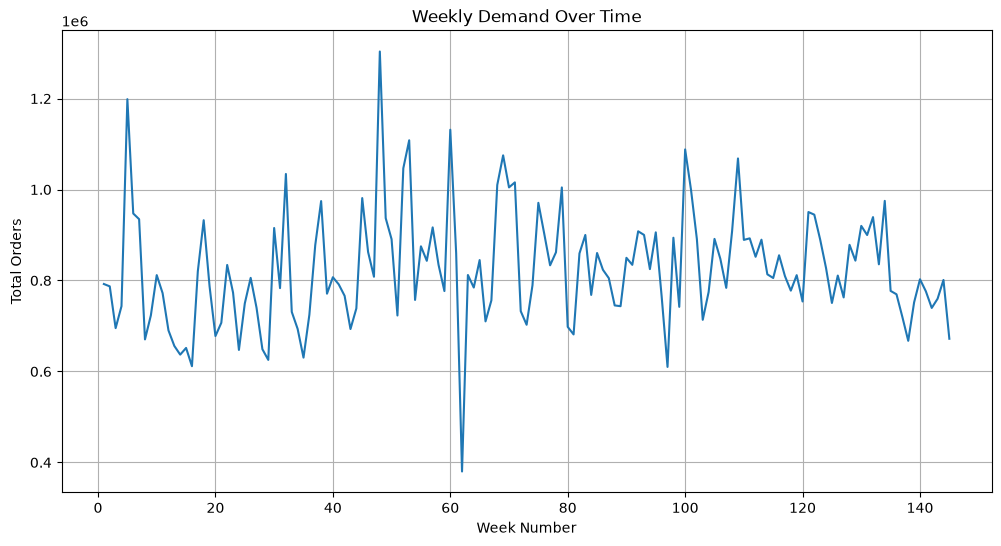

In [44]:
# # Ensure the date column is in datetime format and exists in your dataset
# train_data['week'] = pd.to_datetime(train_data['week'])  # Replace 'week' with the correct date column

# # Aggregate demand by week
# demand_over_time = train_data.groupby('week')['num_orders'].sum()  # Replace 'num_orders' if necessary

# # Plot the demand over time
# import matplotlib.pyplot as plt

# plt.figure(figsize=(12, 6))
# plt.plot(demand_over_time.index, demand_over_time.values, label="Total Demand")
# plt.title("Weekly Demand Over Time")
# plt.xlabel("Date")
# plt.ylabel("Total Orders")
# plt.legend()
# plt.show()

# Aggregate total demand by week
demand_over_time = (
    train_data.groupby("week")["num_orders"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(12, 6))
plt.plot(
    demand_over_time.index,
    demand_over_time.values
)

plt.title("Weekly Demand Over Time")
plt.xlabel("Week Number")
plt.ylabel("Total Orders")
plt.grid(True)
plt.show()

## DEMAND BY FULFILMENT CENTER

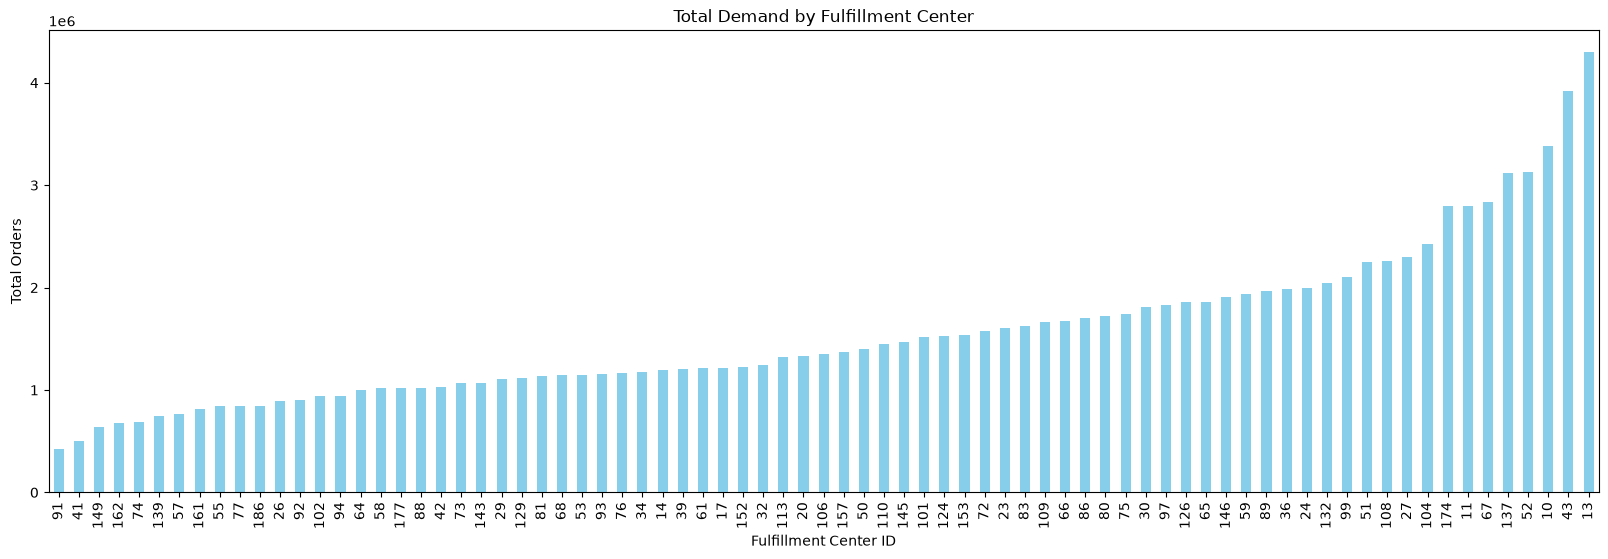

In [45]:
# Aggregate demand by center
center_demand = train_data.groupby('center_id')['num_orders'].sum().sort_values()  # Replace 'center_id' and 'num_orders' as needed

# Plot demand by center
plt.figure(figsize=(20, 6))
center_demand.plot(kind='bar', color='skyblue')
plt.title("Total Demand by Fulfillment Center")
plt.xlabel("Fulfillment Center ID")
plt.ylabel("Total Orders")
plt.show()

## DEMAND BY MEAL TIME

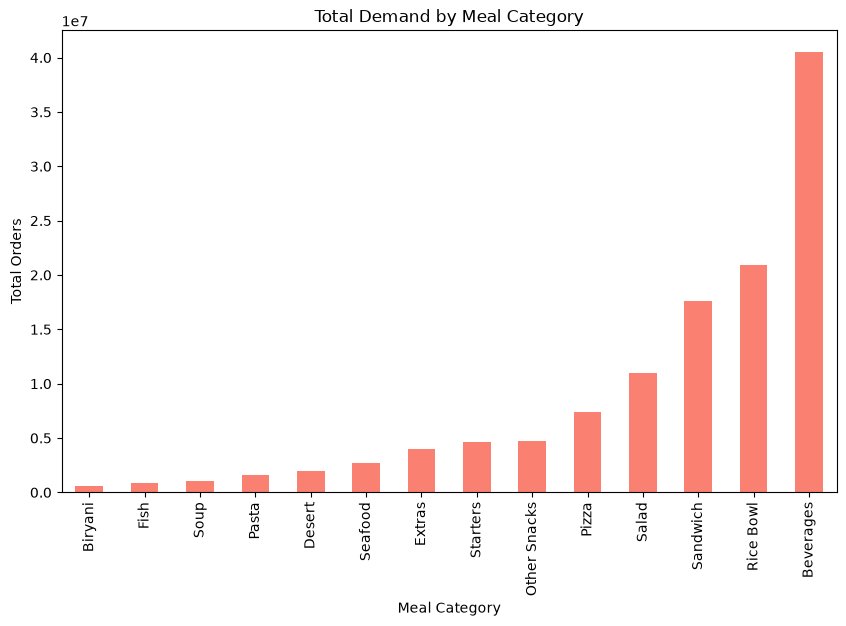

In [46]:
# Merge meal info with the main training dataset to get 'category' and other meal details
train_with_meal_info = train_data.merge(meal_info_data, on='meal_id', how='left')  # Ensure 'meal_id' is the correct join key

# Aggregate demand by meal category
meal_demand = train_with_meal_info.groupby('category')['num_orders'].sum().sort_values()  # Replace 'category' and 'num_orders' as necessary

# Plot demand by meal category
plt.figure(figsize=(10, 6))
meal_demand.plot(kind='bar', color='salmon')
plt.title("Total Demand by Meal Category")
plt.xlabel("Meal Category")
plt.ylabel("Total Orders")
plt.show()

### DATA VISUALISATION ###

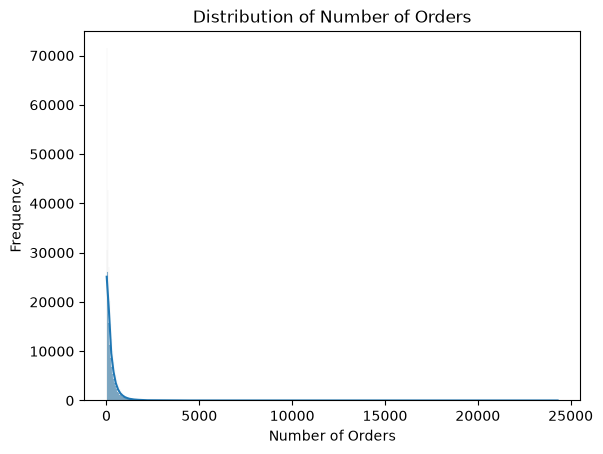

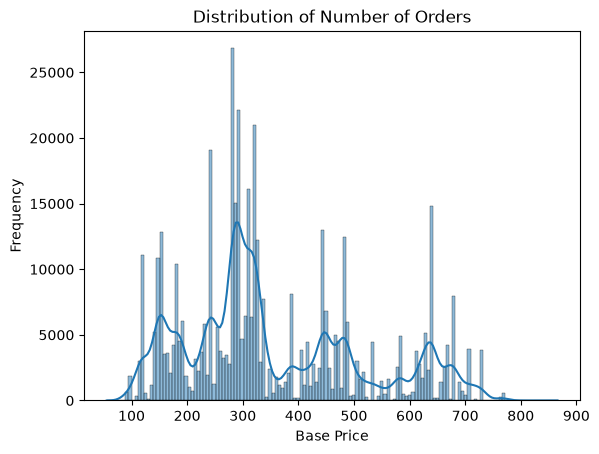

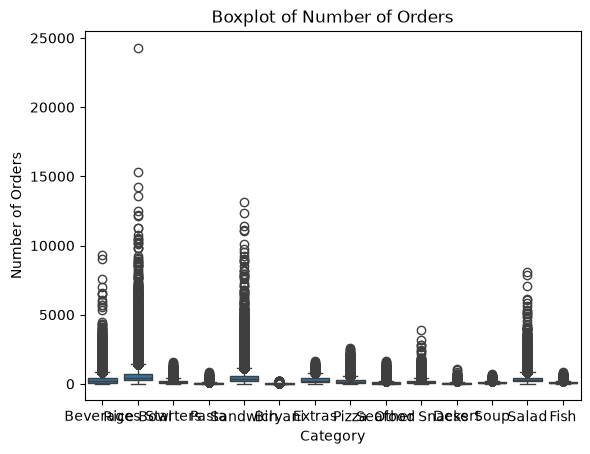

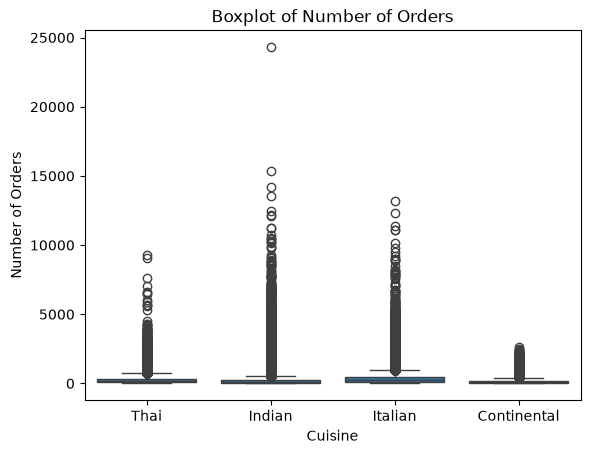

In [47]:
# train.plot(kind = "scatter", x = "week", y = "num_orders",
#            title = "Number of Orders by Week", xlabel = "Week Number",
#            ylabel = "Number of Orders", color = "blue", grid = True)

# # train.plot(kind = "scatter", x = "week", y = "num_orders", color ='maroon', 
# #         width = 0.4)
# plt.xlabel("Week number")
# plt.ylabel("Number of orders")
# plt.title("Number of Orders by Week")
# plt.show()

# Histogram for num_orders distribution
sns.histplot(train['num_orders'], kde=True)
plt.title("Distribution of Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Frequency")
plt.show()

sns.histplot(train['base_price'], kde=True)
plt.title("Distribution of Number of Orders")
plt.xlabel("Base Price")
plt.ylabel("Frequency")
plt.show()

# Boxplot for num_orders to see outliers
sns.boxplot(y=train['num_orders'], x=train['category'])
plt.title("Boxplot of Number of Orders")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.show()

sns.boxplot(y=train['num_orders'], x=train['cuisine'])
plt.title("Boxplot of Number of Orders")
plt.xlabel("Cuisine")
plt.ylabel("Number of Orders")
plt.show()

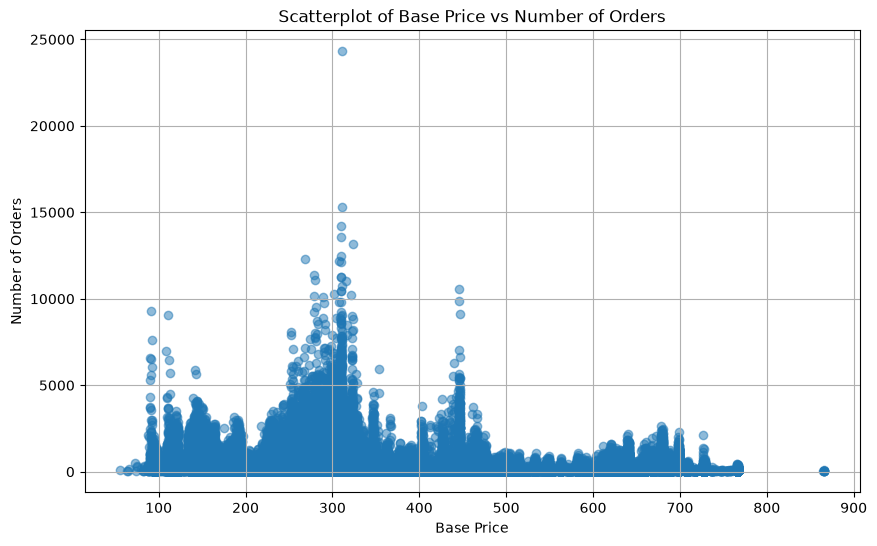

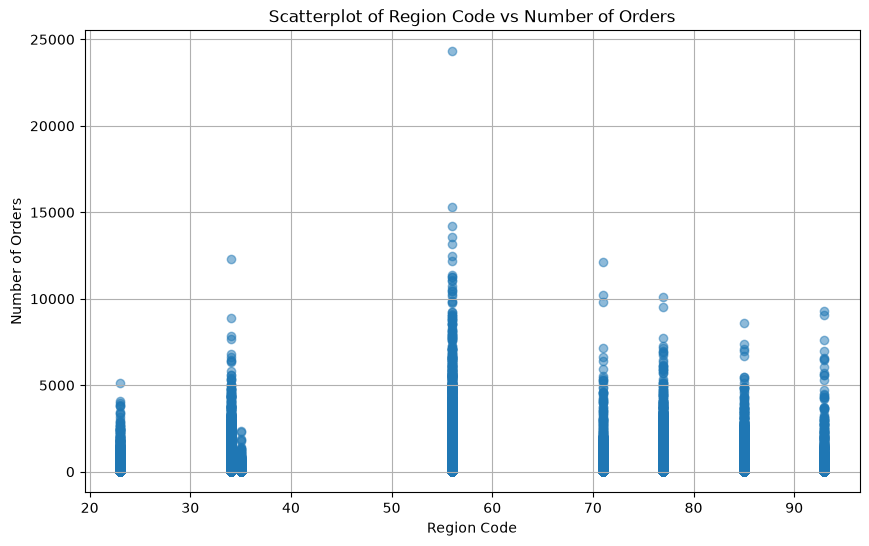

In [48]:
# Plot Scatterplot
plt.figure(figsize=(10, 6))  # Set the figure size
plt.scatter(train['base_price'], train['num_orders'], alpha=0.5)  # Create a scatter plot
plt.title('Scatterplot of Base Price vs Number of Orders')  # Set the title of the plot
plt.xlabel('Base Price')  # Set the x-axis label
plt.ylabel('Number of Orders')  # Set the y-axis label
plt.grid(True)  # Enable grid
plt.show()  # Display the plot

# Plot Scatterplot
plt.figure(figsize=(10, 6))  # Set the figure size
plt.scatter(train['region_code'], train['num_orders'], alpha=0.5)  # Create a scatter plot
plt.title('Scatterplot of Region Code vs Number of Orders')  # Set the title of the plot
plt.xlabel('Region Code')  # Set the x-axis label
plt.ylabel('Number of Orders')  # Set the y-axis label
plt.grid(True)  # Enable grid
plt.show()  # Display the plot

### COUNT OF CATEGORY ###

Index(['Beverages', 'Rice Bowl', 'Sandwich', 'Pizza', 'Starters',
       'Other Snacks', 'Desert', 'Salad', 'Pasta', 'Seafood', 'Biryani',
       'Extras', 'Soup', 'Fish'],
      dtype='str', name='category')


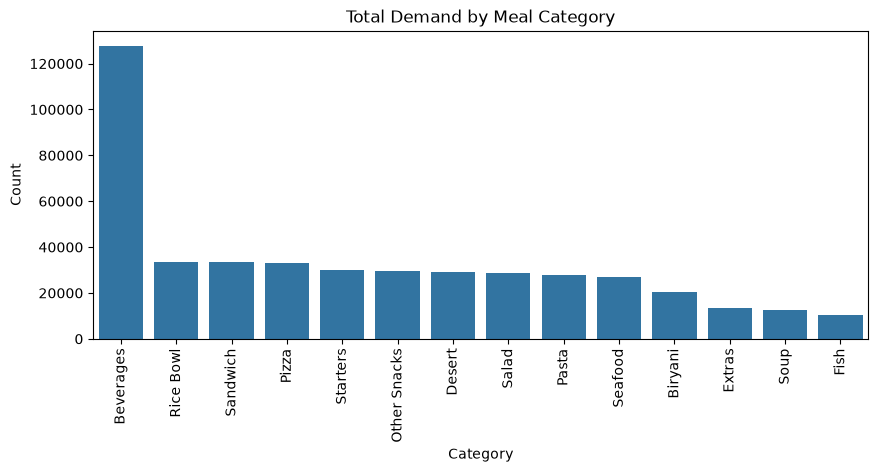

In [49]:
# Calculate the order of "category" in meal_info.csv dataset based on the counts, sorted from greatest to least
category_order = train["category"].value_counts().index
print(category_order)
# Figure size (10, 4) which shows width and height of plot.
plt.figure(figsize = (10, 4)) 

# Count plot for "category"
sns.countplot(data = train, x = "category", order = category_order)

# Plot details
plt.xlabel("Category")
plt.xticks(rotation = 90)
plt.ylabel("Count")
plt.title("Total Demand by Meal Category")

# Show the plot
plt.show()

### COUNT OF CUISINE ###

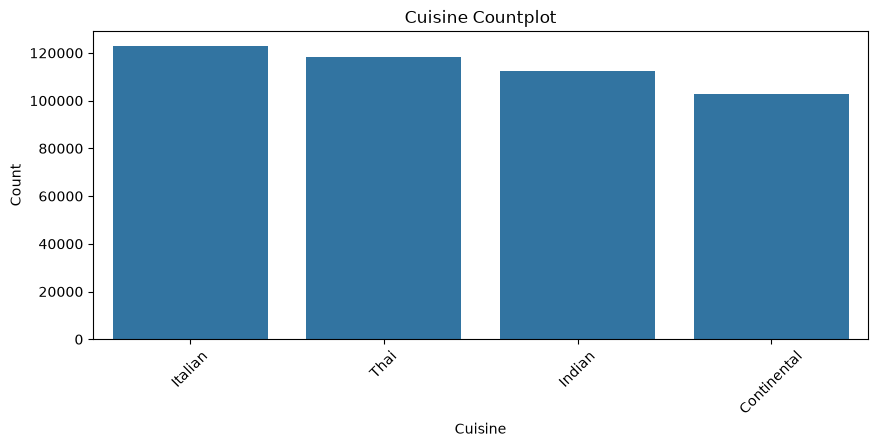

In [50]:
# Calculate the order of "cuisine" based on the counts, sorted from greatest to least
cuisine_order = train["cuisine"].value_counts().index

# Figure size (10, 4)
plt.figure(figsize = (10, 4))

# Count plot for "cuisine"
sns.countplot(data = train, x = "cuisine", order = cuisine_order)

# Plot details
plt.xlabel("Cuisine")
plt.xticks(rotation = 45)
plt.ylabel("Count")
plt.title("Cuisine Countplot")

# Show the plot
plt.show()

### Heatmap Analysis: Key Feature Correlations with Number of Orders ###

In [51]:
# Initialize the LabelEncoder
label_encoder = preprocessing.LabelEncoder()

# Iterate through each dataset in the data list
for dataset in data:

    # Apply LabelEncoder to each specified column independently
    for col in ["center_type", "category", "cuisine"]:
        dataset[col] = label_encoder.fit_transform(dataset[col])
    print(dataset[col])

0         3
1         3
2         3
3         1
4         1
         ..
456543    1
456544    1
456545    2
456546    2
456547    2
Name: cuisine, Length: 456548, dtype: int64
0        3
1        3
2        3
3        1
4        1
        ..
32568    1
32569    1
32570    2
32571    2
32572    2
Name: cuisine, Length: 32573, dtype: int64


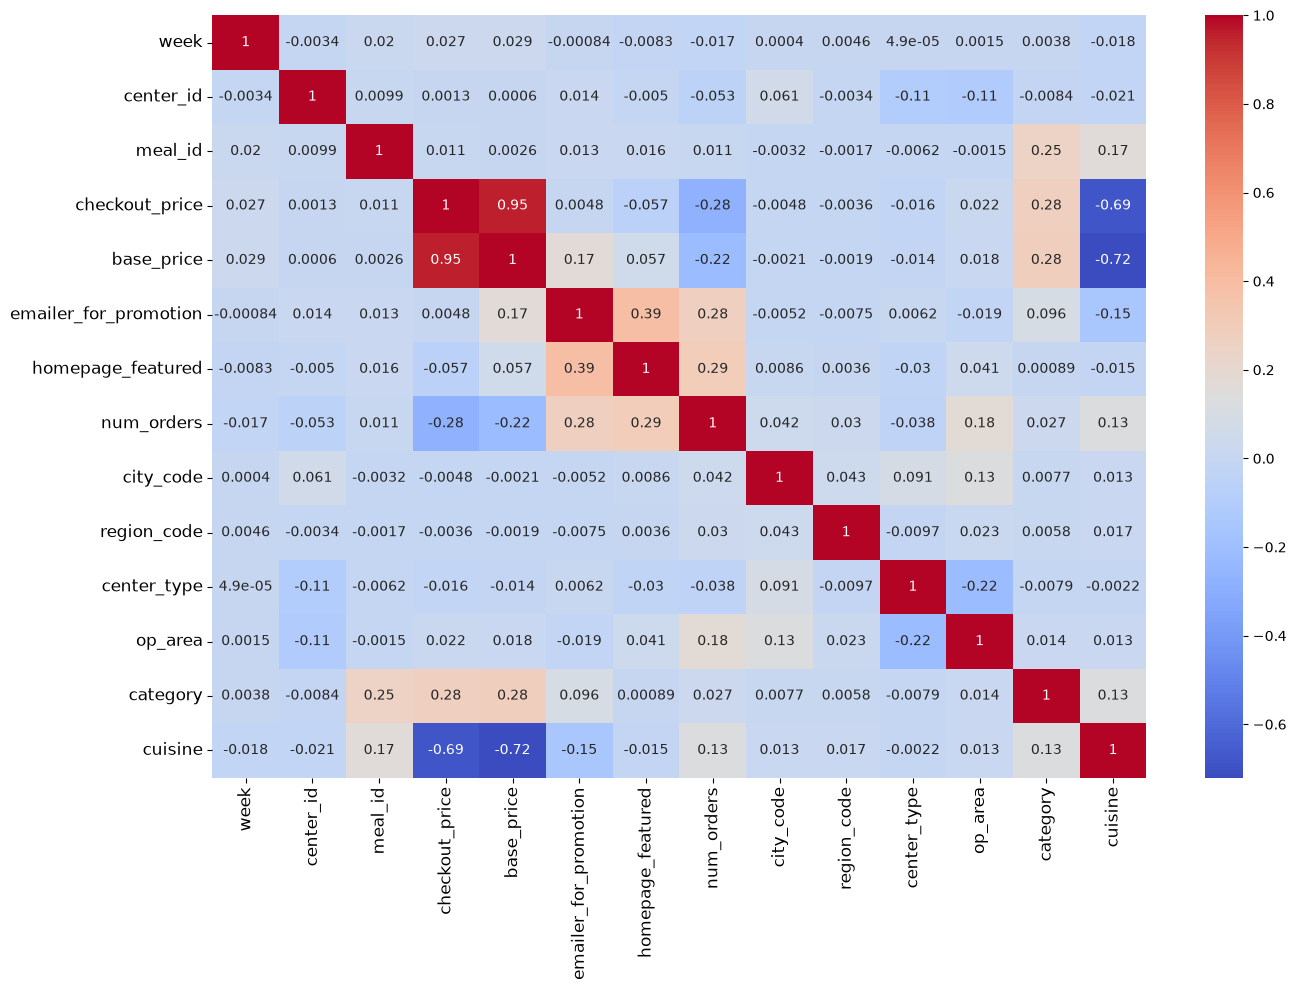

In [52]:
# Figure size
plt.figure(figsize = (14, 10))
# Plot labels
sns.heatmap(train.corr(), cmap = "coolwarm", annot = True)
plt.xticks(rotation = 90, fontsize = 12)
plt.yticks(fontsize = 12)
plt.tight_layout()
plt.show()

## CORRELATION MATRIX (HEATMAP)

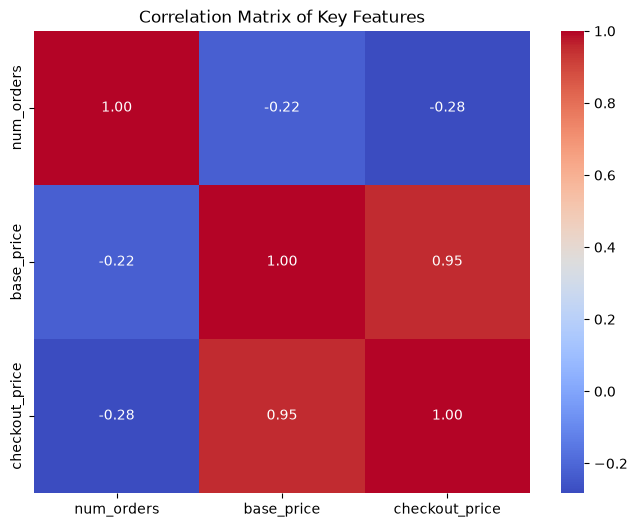

In [53]:
import seaborn as sns

# Select relevant numerical columns, adjust these column names as needed
corr_matrix = train_data[['num_orders', 'base_price', 'checkout_price']].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Key Features")
plt.show()

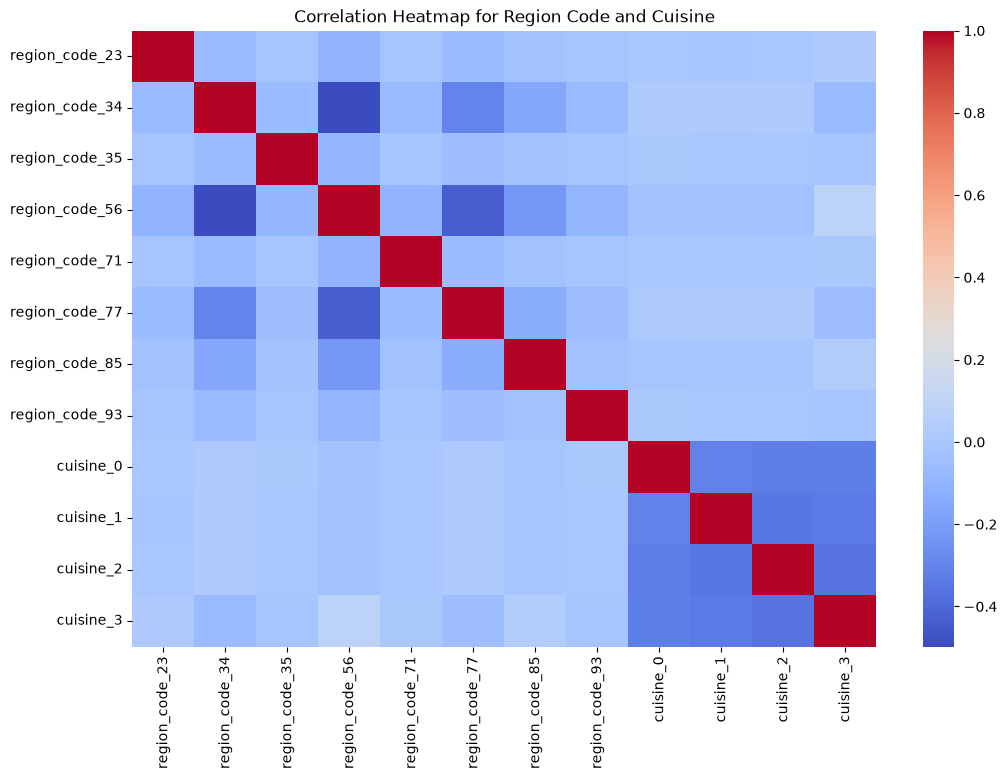

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Check if the columns 'region_code' and 'cuisine' are present
if 'region_code' in train.columns and 'cuisine' in train.columns:
    # Copy data to avoid modifying the original DataFrame
    train_data_encoded = train[['region_code', 'cuisine']].copy()
    
    # Apply one-hot encoding to both columns
    train_data_encoded = pd.get_dummies(train_data_encoded, columns=['region_code', 'cuisine'])
    
    # Compute the correlation matrix
    corr_matrix = train_data_encoded.corr()
    
    # Plot the heatmap for the one-hot encoded region_code and cuisine features
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", cbar=True)
    plt.title("Correlation Heatmap for Region Code and Cuisine")
    plt.show()
else:
    print("Columns 'region_code' or 'cuisine' not found in the DataFrame.")


### ACTUAL VS PREDICTED DEMAND (LINE PLOT)

## Model Development and Evaluation

Three regression models are evaluated for weekly food-demand prediction:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

A time-based validation strategy is used so that earlier weeks are used for training and later weeks are used for validation. This better reflects the real-world forecasting scenario, where future demand must be predicted from historical observations.

In [55]:
# Sort the training data chronologically
model_data = train_data.sort_values("week").copy()

# Use the last 20% of observations as validation data
split_index = int(len(model_data) * 0.8)

train_model = model_data.iloc[:split_index]
val_model = model_data.iloc[split_index:]

# Separate features and target
X_train = train_model.drop(columns=["num_orders", "id"])
y_train = train_model["num_orders"]

X_val = val_model.drop(columns=["num_orders", "id"])
y_val = val_model["num_orders"]

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Training weeks:", X_train["week"].min(), "to", X_train["week"].max())
print("Validation weeks:", X_val["week"].min(), "to", X_val["week"].max())

Training data: (365238, 7)
Validation data: (91310, 7)
Training weeks: 1 to 118
Validation weeks: 118 to 145


In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)

rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
r2_lr = r2_score(y_val, y_pred_lr)

print(f"Linear Regression RMSE: {rmse_lr:.2f}")
print(f"Linear Regression R²: {r2_lr:.4f}")

Linear Regression RMSE: 331.68
Linear Regression R²: 0.1789


In [57]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_val)

rmse_dt = np.sqrt(mean_squared_error(y_val, y_pred_dt))
r2_dt = r2_score(y_val, y_pred_dt)

print(f"Decision Tree RMSE: {rmse_dt:.2f}")
print(f"Decision Tree R²: {r2_dt:.4f}")

Decision Tree RMSE: 310.82
Decision Tree R²: 0.2789


In [58]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.2f}")
print(f"Random Forest R²: {r2_rf:.4f}")

Random Forest RMSE: 243.53
Random Forest R²: 0.5573


In [59]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf
    ],
    "R²": [
        r2_lr,
        r2_dt,
        r2_rf
    ]
})

model_comparison = model_comparison.sort_values(
    "RMSE"
).reset_index(drop=True)

model_comparison

,Model,RMSE,R²
0,Random Forest,243.528579,0.557330
1,Decision Tree,310.822154,0.278886
2,Linear Regression,331.678321,0.178866


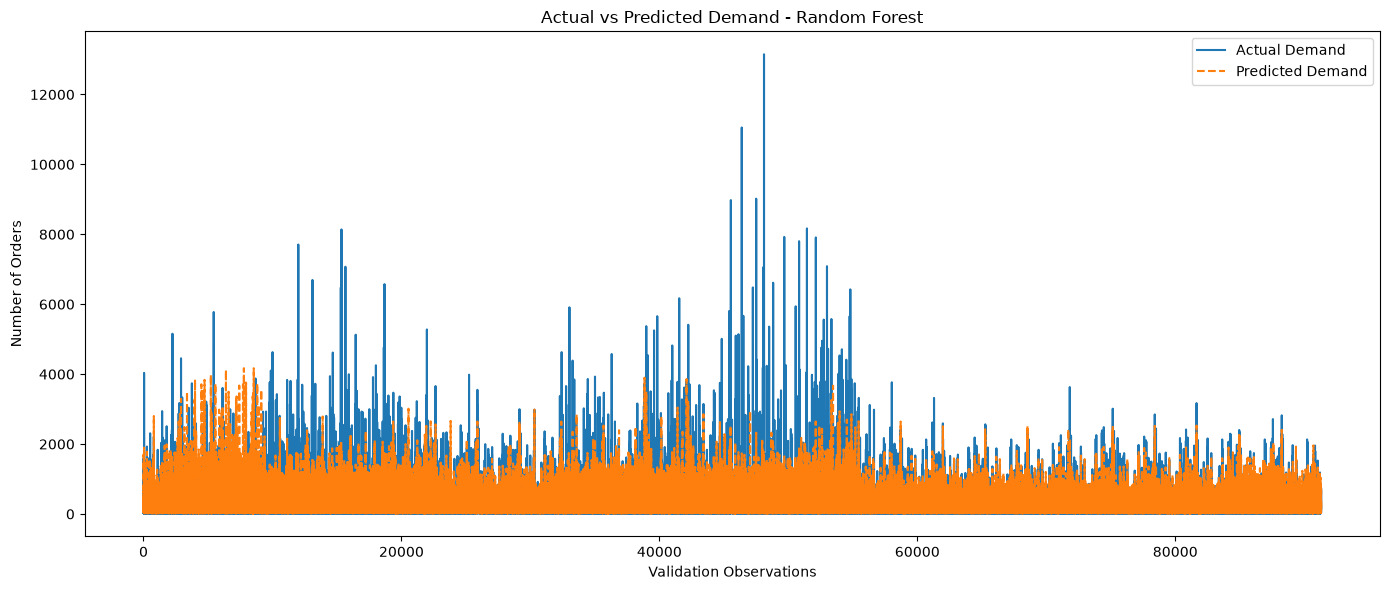

In [60]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_val.values,
    label="Actual Demand"
)

plt.plot(
    y_pred_rf,
    label="Predicted Demand",
    linestyle="--"
)

plt.title("Actual vs Predicted Demand - Random Forest")
plt.xlabel("Validation Observations")
plt.ylabel("Number of Orders")
plt.legend()
plt.tight_layout()
plt.show()

### Prediction Error Distribution

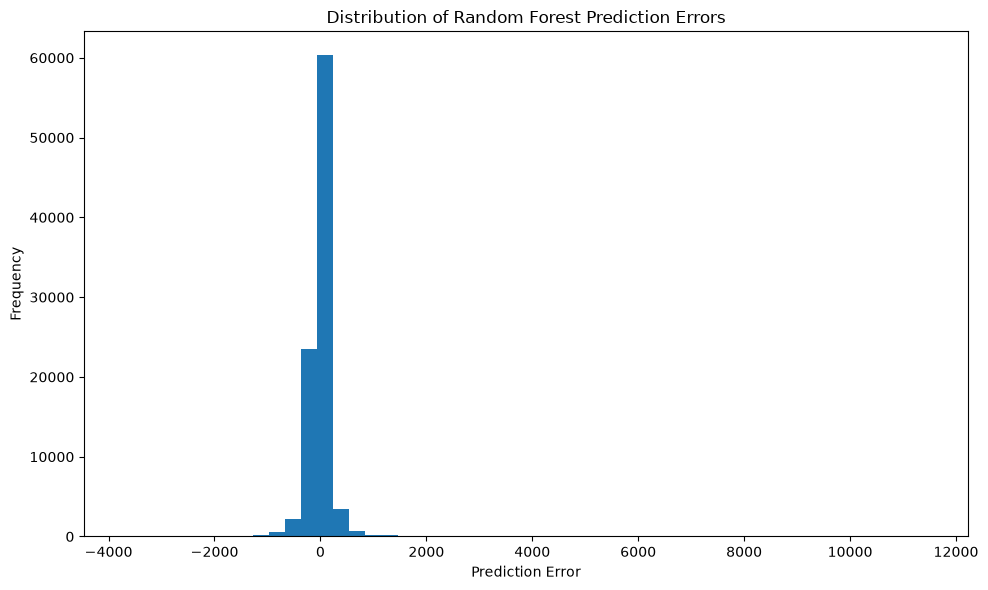

In [61]:
errors = y_val - y_pred_rf

plt.figure(figsize=(10, 6))

plt.hist(
    errors,
    bins=50
)

plt.title("Distribution of Random Forest Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [62]:
# Limit parallel processing to avoid excessive system resource usage
rf_model.n_jobs = 1

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
3,checkout_price,0.240864
2,meal_id,0.236625
1,center_id,0.169400
4,base_price,0.128726
6,homepage_featured,0.090641
0,week,0.084722
5,emailer_for_promotion,0.049022


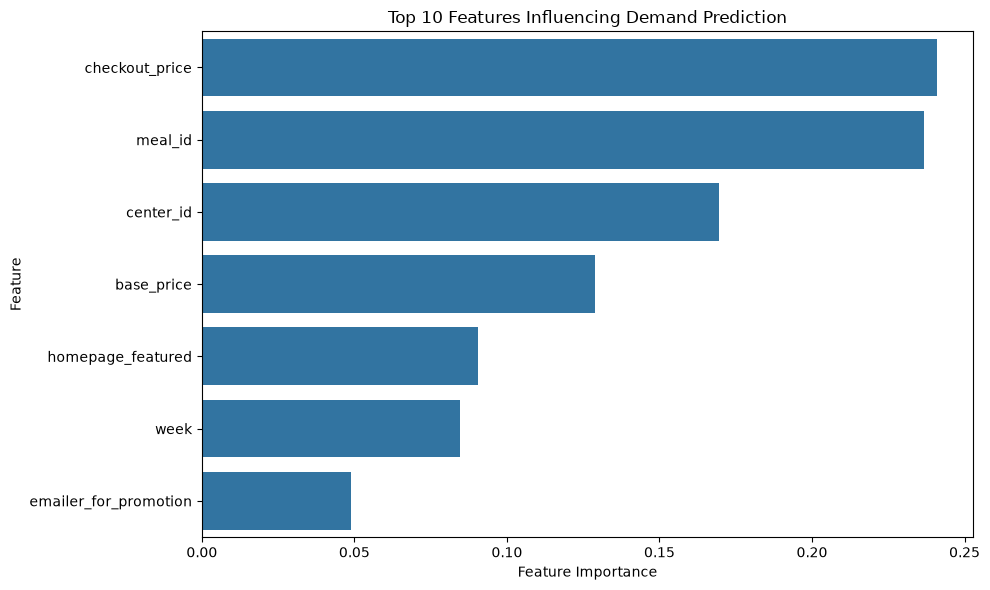

In [63]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Influencing Demand Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [64]:
# X_test_final = test_data.copy()

# final_predictions = rf_model.predict(X_test_final)

# predictions_df = pd.DataFrame({
#     "id": test_data["id"],
#     "num_orders": final_predictions
# })

# predictions_df.head()

# Prepare test data using the same features as the final model
X_test_final = test_data.drop(columns=["id"]).copy()

# Generate demand predictions
final_predictions = rf_model.predict(X_test_final)

# Create prediction dataframe
predictions_df = pd.DataFrame({
    "id": test_data["id"],
    "num_orders": final_predictions
})

display(predictions_df.head())

,id,num_orders
0,1028232,833.23
1,1127204,484.30
2,1212707,184.51
3,1082698,72.73
4,1400926,289.72


In [65]:
prediction_file = "food_demand_predictions.csv"

predictions_df.to_csv(
    prediction_file,
    index=False
)

print(f"✅ Predictions saved to {prediction_file}")

✅ Predictions saved to food_demand_predictions.csv


In [66]:
print("Prediction rows:", len(predictions_df))
print("Expected rows:", len(test_data))

print("\nMissing predictions:")
print(predictions_df["num_orders"].isnull().sum())

print("\nPrediction statistics:")
print(predictions_df["num_orders"].describe())

Prediction rows: 32573
Expected rows: 32573

Missing predictions:
0

Prediction statistics:
count    32573.000000
mean       281.708531
std        372.248776
min         13.830000
25%         77.100000
50%        165.650000
75%        331.880000
max       5857.680000
Name: num_orders, dtype: float64


## Final Model Training

Random Forest achieved the best validation performance among the evaluated models. The final model is therefore retrained using the complete historical training dataset before generating predictions for the unseen test period.

In [67]:
# Prepare the complete historical training data
X_full = train_data.drop(columns=["num_orders", "id"])
y_full = train_data["num_orders"]

# Prepare the test data using the same features
X_test_final = test_data.drop(columns=["id"])

# Train the final Random Forest model on all available training data
final_rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(X_full, y_full)

print("✅ Final Random Forest model trained successfully.")

✅ Final Random Forest model trained successfully.


In [68]:
# Generate predictions for the unseen test data
final_predictions = final_rf_model.predict(X_test_final)

final_predictions_df = pd.DataFrame({
    "id": test_data["id"],
    "num_orders": final_predictions
})

display(final_predictions_df.head())

,id,num_orders
0,1028232,433.55
1,1127204,168.36
2,1212707,201.57
3,1082698,77.45
4,1400926,69.60


In [69]:
print("Prediction rows:", len(final_predictions_df))
print("Expected rows:", len(test_data))

print("\nMissing predictions:")
print(final_predictions_df["num_orders"].isnull().sum())

print("\nFinal prediction statistics:")
print(final_predictions_df["num_orders"].describe())

Prediction rows: 32573
Expected rows: 32573

Missing predictions:
0

Final prediction statistics:
count    32573.000000
mean       268.290522
std        415.005818
min         13.680000
25%         64.910000
50%        147.890000
75%        297.050000
max       4742.880000
Name: num_orders, dtype: float64


In [70]:
final_prediction_file = "food_demand_predictions.csv"

final_predictions_df.to_csv(
    final_prediction_file,
    index=False
)

print(f"✅ Final predictions saved to: {final_prediction_file}")

✅ Final predictions saved to: food_demand_predictions.csv


In [71]:
final_rf_model.n_jobs = 1
final_feature_importance = pd.DataFrame({
    "Feature": X_full.columns,
    "Importance": final_rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(final_feature_importance)

,Feature,Importance
3,checkout_price,0.236943
2,meal_id,0.227365
1,center_id,0.173103
4,base_price,0.138814
6,homepage_featured,0.086893
0,week,0.083298
5,emailer_for_promotion,0.053584


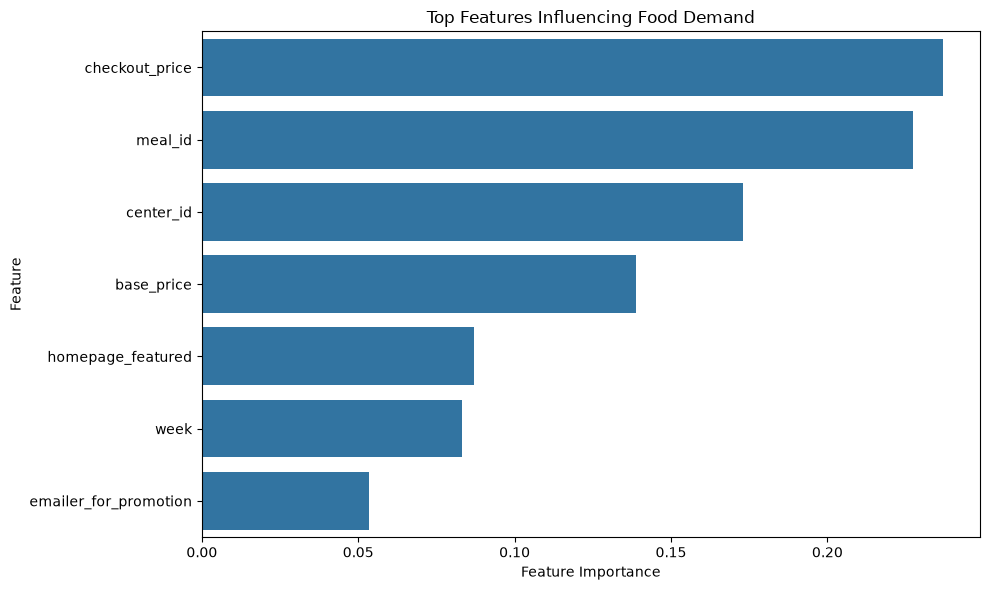

In [72]:
top_features = final_feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Features Influencing Food Demand")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Model Selection

Random Forest achieved the best validation performance among the three evaluated models.

| Model | RMSE | R² |
|---|---:|---:|
| Random Forest | 243.53 | 0.5573 |
| Decision Tree | 310.82 | 0.2789 |
| Linear Regression | 331.68 | 0.1789 |

Random Forest was selected as the final model because it produced the lowest RMSE and the highest R² on the time-based validation dataset.

The final Random Forest model was subsequently retrained using the complete historical training dataset before generating predictions for the unseen test period.

## Conclusion

This project developed a machine-learning approach for food demand forecasting using historical order, pricing, promotion, meal, and fulfilment-center information.

Exploratory analysis was used to understand demand patterns and relationships between demand and the available features. Three regression models were evaluated using a time-based validation strategy: Linear Regression, Decision Tree, and Random Forest.

Random Forest achieved the strongest validation performance and was selected as the final model. The final model was trained using the complete historical training dataset and used to generate demand predictions for the unseen test period.

The analysis demonstrates an end-to-end machine-learning workflow from data preparation and exploratory analysis through model evaluation and final demand prediction.